# **Forecasting Food Consumer Price Index**
#### Adam Kahle, MSBA

The Food Consumer Price Index (CPI), supplied by the Federal Reserve, examines relative changes in the price of food. The index aggregates everything from the meats and dairies to cereals and bakery products. In many industries, especially Finance with practices like FP&A and Investment Banking, pricing models are built under the assumption of a 2% - 3% annual growth rate. Historically, this rate has actually be quite innacurate. Some financial analysts and economists may use methods like a Moving Average, Linear Regression, Exponential Smoothing, or Auto Regressive Integrated Moving Average (ARIMA). While these methods provide substantial improvements over the 2%-3% assumption, they are still fairly basic in the world of Forecasting.

This document examines the progression of Forecasting models on the Food Consumer Price Index and backtests their effectiveness with a rolling window approach. The champion model will be selected based on performance metrics like RMSE, MAE, MAPE, while considering Occam's Razor.

Many of these advanced models can be further enhanced with exogeneous predictors (aka external data). Some I recommend starting with are the USD trade-weighted index, M2 Money Supply, 5-Year Breakeven Inflation Rate, Crude Oil Prices (Impacts Supply Chain), Producer Price Index by Commodity: Farm Products. All of these tables can be found on the Federal Reserve website.

#### **Models include:**

**Baselines**
- Naive
- Rolling Average
- Seasonal Variations of Naive & Rolling Average
- % Assumptions

**Statistical**
- Linear Regression
- Exponential Smoothing, and Holt
- ARIMA
    - Parameters selected by examining MSTL, ACF & PACF plots, ADF Tests, KPSS Tests, and Acorr-Ljungbx Tests

**Statistical Learning**
- AutoARIMA and AutoETS
- A Customized SARIMAX with a Fourier Series

**Classical Machine Learning**
- K Nearest Neighbors
- Random Foresests
- Extreme Gradient Boosting (XGBoost)

**Deep Learning**
- Bidirectional Temporal Convolutional Network (BiTCN)
- Recurrent Neural Network (RNN)
- Long Short Term Memory (LSTM)
- Gated Recurrent Network (GRU)
- Neural Basis Expansion Analysis for Interpretable Time Series (N-BEATS)
- Neural Hierarchical Interpolation for Time Series (N-HITS)

**Transformer**
- TimeGPT

**Customized Ensemble**
- An optimized mix of all the models above

In [1]:
## imports
import sys
import os
import warnings
from dotenv import load_dotenv
import time
from functools import reduce, partial

# ---- pytorch-lightning / lightning compatibility patch ----
# neuralforecast v3 still uses 'pytorch_lightning' internally, but this environment
# has 'lightning.pytorch' as the primary package. The old sys.modules top-level patch
# is insufficient because all pytorch_lightning.* sub-module entries remain in
# sys.modules and are used directly by neuralforecast's module-level imports.
# Fix: load both packages first, then redirect every pytorch_lightning.* key to its
# lightning.pytorch.* equivalent BEFORE importing neuralforecast.
import pytorch_lightning      # triggers loading all pytorch_lightning.* into sys.modules
import lightning.pytorch      # load target package (also loads its sub-modules)
for _pl_key in list(sys.modules.keys()):
    if _pl_key.startswith('pytorch_lightning'):
        _lpl_key = _pl_key.replace('pytorch_lightning', 'lightning.pytorch', 1)
        if _lpl_key in sys.modules:
            sys.modules[_pl_key] = sys.modules[_lpl_key]
del _pl_key, _lpl_key
# ---- end patch ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## time series imports
from statsforecast import StatsForecast
from utilsforecast.plotting import plot_series
from utilsforecast.losses import rmse, mae, mape
from utilsforecast.evaluation import evaluate
from coreforecast.differences import num_diffs, num_seas_diffs
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsforecast.models import (
    SimpleExponentialSmoothing,
    HistoricAverage,
    Naive,
    WindowAverage,
    SeasonalNaive,
    SeasonalWindowAverage,
    Holt,
    HoltWinters,
    AutoETS,
    ARIMA,
    AutoARIMA,
)

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from neuralforecast import NeuralForecast
from neuralforecast.models import BiTCN, GRU, RNN, LSTM, NBEATS, NHITS
from neuralforecast.auto import (
    AutoBiTCN,
    AutoGRU,
    AutoRNN,
    AutoLSTM,
    AutoNBEATS,
    AutoNHITS
)

from nixtla import NixtlaClient

import gurobipy as gp
from gurobipy import GRB

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)
import mlflow
import optuna
from optuna.samplers import TPESampler
import optuna.visualization as vis
import plotly.graph_objects as go
from plotly.io import show

In [2]:
## read csv
df = pd.read_csv("CPIUFDSL.csv").assign(
    observation_date = lambda x: pd.to_datetime(x.observation_date),
    ds = lambda x: x.observation_date,
    y = lambda x: x.CPIUFDSL,
    unique_id = lambda x: 'CPIUFDSL'
    ).drop(columns = ['observation_date','CPIUFDSL'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ds         952 non-null    datetime64[ns]
 1   y          951 non-null    float64       
 2   unique_id  952 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 22.4+ KB


In [3]:
## impute missing with a simple forward fill
df['y'] = df['y'].ffill()

There is one missing entry in the dataset, so we used a simple forward fill to impute.

In [4]:
## visualize
plot_series(df, engine = 'plotly')

The trend looks non-stationary. A log transformation or differencing may be needed when modeling.

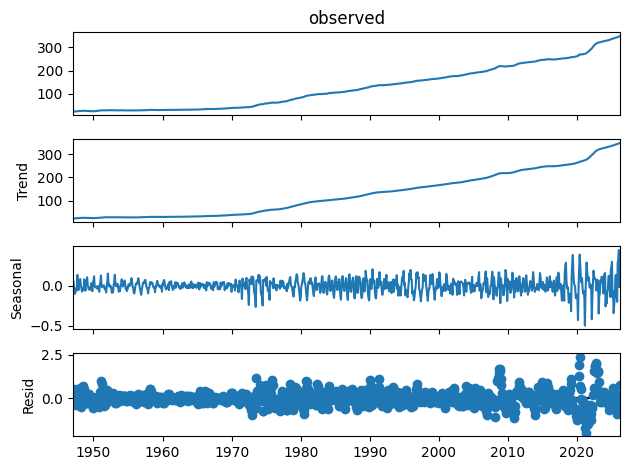

In [5]:
## seasonal decomposition
ts = df.set_index('ds')['y']
res = MSTL(ts, periods = 12).fit()
res.plot();

There is minimal seasonality, enough to consider it in models. There is clear heteroscadicity, the variance in the residuals increases overtime.

In [6]:
## naive baseline models
mlflow.set_experiment("statsforecast_naive_cpi")

naive_models = [
    HistoricAverage(),
    Naive(),
    SeasonalNaive(season_length=12),
    WindowAverage(window_size=12),
    SeasonalWindowAverage(season_length=12, window_size=12),
]

naive_sf = StatsForecast(models=naive_models, freq='MS')

with mlflow.start_run(run_name="naive_cv"):
    naive_results = naive_sf.cross_validation(
        df=df, h=12, step_size=12, n_windows=30, input_size=120
    )
    naive_cv_evaluation = evaluate(
        df=naive_results.drop(columns='cutoff'),
        metrics=[rmse, mae, mape],
        target_col='y',
        train_df=df
    )
    _cols = [c for c in naive_cv_evaluation.columns if c not in ('unique_id', 'metric')]
    for _, _row in naive_cv_evaluation.iterrows():
        for _col in _cols:
            mlflow.log_metric(f"{_col}_{_row['metric']}", float(_row[_col]))

display(naive_cv_evaluation.T)


,0,1,2
unique_id,CPIUFDSL,CPIUFDSL,CPIUFDSL
metric,rmse,mae,mape
HistoricAverage,33.677392,30.777609,0.131833
Naive,5.392973,3.618539,0.015147
SeasonalNaive,8.538056,6.495472,0.027308
WindowAverage,8.711575,6.45538,0.027063
SeasWA,NaN,NaN,NaN


In [104]:
## flat rate annual growth
_h          = 12
_input_size = 120
_step_size  = 12
_n_windows  = 30

growth_rates   = [0.02, 0.025, 0.03]
growth_results = []

for annual_growth in growth_rates:
    monthly_growth = (1 + annual_growth) ** (1 / 12) - 1

    actuals   = []
    forecasts = []

    for window in range(_n_windows):
        train_end = _input_size + window * _step_size
        train_w   = df.iloc[:train_end]
        test_w    = df.iloc[train_end:train_end + _h]

        if len(test_w) < _h:
            continue

        last_y = train_w["y"].iloc[-1]
        y_hat  = [last_y * (1 + monthly_growth) ** step for step in range(1, _h + 1)]

        actuals.extend(test_w["y"].values)
        forecasts.extend(y_hat)

    actuals   = np.array(actuals)
    forecasts = np.array(forecasts)

    rmse_val = np.sqrt(np.mean((actuals - forecasts) ** 2))
    mae_val  = np.mean(np.abs(actuals - forecasts))
    mape_val = np.mean(np.abs((actuals - forecasts) / actuals)) * 100

    growth_results.append({
        "annual_growth_%": f"{annual_growth * 100:.1f}%",
        "rmse":             rmse_val,
        "mae":              mae_val,
        "mape":           mape_val,
    })

growth_evaluation = pd.DataFrame(growth_results)
display(growth_evaluation)

,annual_growth_%,rmse,mae,mape
0,2.0%,4.438790,2.508545,0.937508
1,2.5%,4.186559,2.441956,0.926548
2,3.0%,4.074448,2.582191,0.985316


In [7]:
## unit testing KPSS
stat, p_value, lags, crit = kpss(df['y'], regression= 'c')

print("KPSS TEST RESULTS")
print("------------------")
print(f"KPSS Statistic: {stat:.4f}")
print(f"P-value:        {p_value:.4f}")
print(f"Lags used:      {lags}")
print("\nCritical values:")
print(f"  10%: {crit['10%']}")
print(f"  5%:  {crit['5%']}")
print(f"  2.5%:{crit['2.5%']}")
print(f"  1%:  {crit['1%']}")
print("------------------")

KPSS TEST RESULTS
------------------
KPSS Statistic: 4.6708
P-value:        0.0100
Lags used:      19

Critical values:
  10%: 0.347
  5%:  0.463
  2.5%:0.574
  1%:  0.739
------------------


/var/folders/31/z95ql2qs3rb7tb0_gzly1xdc0000gn/T/ipykernel_93934/761572430.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




In [8]:
## unit testing ADF
result = adfuller(df['y'])

stat = result[0]
p_value = result[1]
lags = result[2]
n_obs = result[3]
crit = result[4]

print("ADF TEST RESULTS")
print("----------------")
print(f"ADF Statistic:  {stat:.4f}")
print(f"P-value:        {p_value:.4f}")
print(f"Lags used:      {lags}")
print(f"Observations:   {n_obs}")

print("\nCritical values:")
print(f"  1%:  {crit['1%']}")
print(f"  5%:  {crit['5%']}")
print(f"  10%: {crit['10%']}")
print("----------------")

ADF TEST RESULTS
----------------
ADF Statistic:  3.5408
P-value:        1.0000
Lags used:      6
Observations:   945

Critical values:
  1%:  -3.4372887850912175
  5%:  -2.8646033071530703
  10%: -2.568401081996585
----------------


The KPSS and ADF tests confirm non-stationarity. We accept the KPSS test and reject the ADF test.

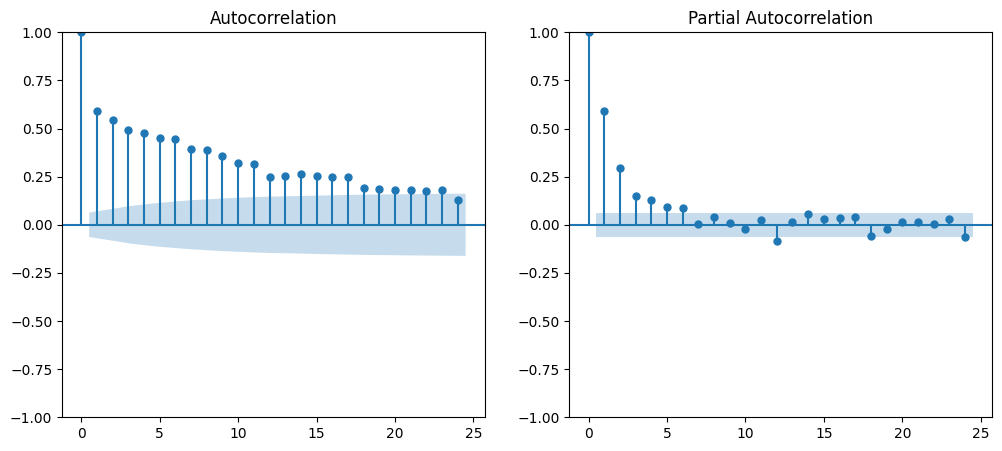

In [9]:
## autocorrelation & differencing
ddf = df['y'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_title("ACF")
axes[1].set_title("PACF")

plot_acf(ddf, lags = 24, ax=axes[0])
plot_pacf(ddf, lags = 24, ax=axes[1])
plt.show()

After differencing once there still appears to be non-stationarity, given the slow decay and early large lag spikes in the PACF plot.

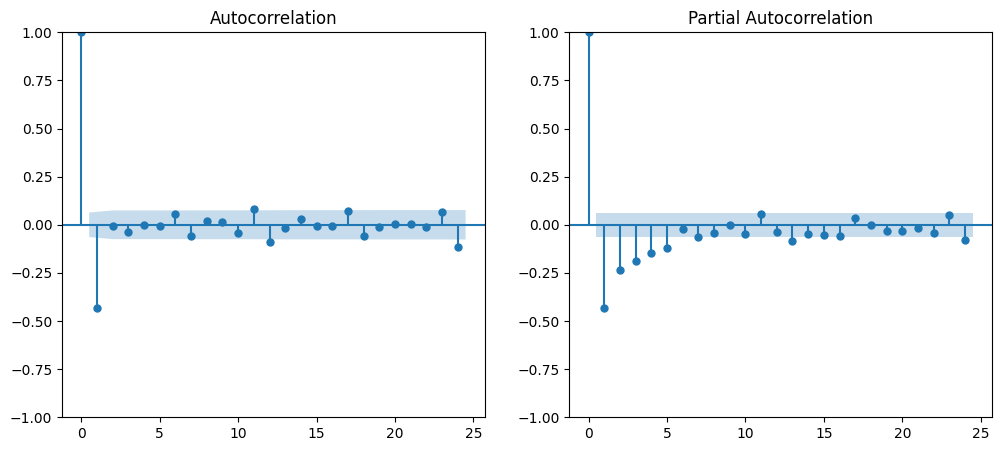

In [10]:
## autocorrelation & differencing
dddf = ddf.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_title("ACF")
axes[1].set_title("PACF")

plot_acf(dddf, lags = 24, ax=axes[0])
plot_pacf(dddf, lags = 24, ax=axes[1])
plt.show()

The first order differencing issolated the velocity, the second order differencing issolated the acceleration. The second order differencing is more appropriate for the series.

In [17]:
## stepping-stone models
mlflow.set_experiment("statsforecast_stepping_stone_cpi")

models = [
    SimpleExponentialSmoothing(alpha=0.5),
    Holt(),
    ## HoltWinters(season_length = 12),
    ARIMA(order=(4, 2, 1), seasonal_order=(2, 0, 2), season_length=12, alias='ARIMA2')
]

exp = StatsForecast(models=models, freq='MS')

with mlflow.start_run(run_name="stepping_stone_cv"):
    exp_results = exp.cross_validation(
        df=df, h=12, step_size=12, n_windows=30, input_size=120
    )
    exp_cv_evaluation = evaluate(
        df=exp_results.drop(columns='cutoff'),
        metrics=[rmse, mae, mape],
        target_col='y',
        train_df=df
    )
    model_cols = [c for c in exp_cv_evaluation.columns if c not in ('unique_id', 'metric')]
    for _, row in exp_cv_evaluation.iterrows():
        for col in model_cols:
            mlflow.log_metric(f"{col}_{row['metric']}", float(row[col]))

display(exp_cv_evaluation.T)

,0,1,2
unique_id,CPIUFDSL,CPIUFDSL,CPIUFDSL
metric,rmse,mae,mape
SES,6.02411,4.160252,0.017405
Holt,2.757831,1.515268,0.006244
ARIMA2,2.901536,1.510475,0.006223


In [19]:
## stat learning with cross validation
mlflow.set_experiment("statsforecast_auto_cpi")

models = [AutoETS(), AutoARIMA()]
stat_learning = StatsForecast(models=models, freq='MS')

with mlflow.start_run(run_name="auto_cv"):
    sl_results = stat_learning.cross_validation(
        df=df, h=12, step_size=12, n_windows=30, input_size=120
    )
    sl_cv_evaluation = evaluate(
        df=sl_results.drop(columns='cutoff'),
        metrics=[rmse, mae, mape],
        target_col='y',
        train_df=df
    )
    model_cols = [c for c in sl_cv_evaluation.columns if c not in ('unique_id', 'metric')]
    for _, row in sl_cv_evaluation.iterrows():
        for col in model_cols:
            mlflow.log_metric(f"{col}_{row['metric']}", float(row[col]))

display(sl_cv_evaluation.T)

,0,1,2
unique_id,CPIUFDSL,CPIUFDSL,CPIUFDSL
metric,rmse,mae,mape
AutoETS,2.732598,1.486258,0.006143
AutoARIMA,2.659879,1.410483,0.005854


In [114]:
## fourier-sarima bayesian search
while mlflow.active_run():
    mlflow.end_run()

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsforecast")
np.seterr(invalid="ignore")

h          = 12
input_size = 120
step_size  = 12
n_windows  = 30

PARAM_BOUNDS = {
    "k": (0, 11),
}

_META_COLS = {"unique_id", "ds", "cutoff", "y"}


def make_fourier_df(df_: pd.DataFrame, k: int, season_length: int = 12) -> pd.DataFrame:
    out = df_.copy()
    for i in range(1, k + 1):
        out[f"sin_{i}"] = np.sin(2 * np.pi * i * out["ds"].dt.month / season_length)
        out[f"cos_{i}"] = np.cos(2 * np.pi * i * out["ds"].dt.month / season_length)
    return out


def _model_col(df: pd.DataFrame) -> str:
    return next(c for c in df.columns if c not in _META_COLS)


def run_cv(k, season_length=12):
    fourier_cols = [f"sin_{i}" for i in range(1, k + 1)] + \
                   [f"cos_{i}" for i in range(1, k + 1)]
    df_feat = make_fourier_df(df.copy(), k, season_length)
    sf = StatsForecast(
        models=[AutoARIMA(season_length=season_length, alias="FourierARIMA")],
        freq="MS"
    )
    cv_df = sf.cross_validation(
        df=df_feat[["unique_id", "ds", "y"] + fourier_cols],
        h=h, step_size=step_size, n_windows=n_windows
    )
    arima_col = _model_col(cv_df)
    cv_df = cv_df.rename(columns={arima_col: "forecast"})
    agg = evaluate(
        df=cv_df.drop(columns=["cutoff"], errors="ignore"),
        metrics=[rmse, mae, mape],
        models=["forecast"],
        target_col="y", id_col="unique_id", time_col="ds"
    )
    return agg, cv_df

def objective(trial):
    k = trial.suggest_int("k", *PARAM_BOUNDS["k"])

    try:
        with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):
            mlflow.log_params({"k": k})
            agg, _ = run_cv(k)
            rmse_val = float(agg.loc[agg["metric"] == "rmse", "forecast"].values[0])
            mae_val  = float(agg.loc[agg["metric"] == "mae",  "forecast"].values[0])
            mape_val = float(agg.loc[agg["metric"] == "mape", "forecast"].values[0])
            mlflow.log_metrics({"rmse": rmse_val, "mae": mae_val, "mape": mape_val})
            results.append({
                "trial": trial.number, "k": k,
                "rmse": rmse_val, "mae": mae_val, "mape": mape_val,
            })
            return rmse_val
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")


results = []
mlflow.set_experiment("fourier_sarima_cpi")

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42, n_startup_trials=10, multivariate=True),
    study_name="fourier_sarima_cpi"
)

with mlflow.start_run(run_name="fourier_sarima_bayesian"):
    study.optimize(objective, n_trials=150, show_progress_bar=True)
    _bp = study.best_params
    mlflow.log_params({"k": _bp["k"]})
    mlflow.log_metric("best_rmse", study.best_value)

results_df = pd.DataFrame(results)

print("\n--- Best Trial ---")
print(f"  RMSE:   {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

if not results_df.empty:
    print("\n--- Top 10 Trials by RMSE ---")
    print(results_df.sort_values("rmse").head(10).to_string(index=False))

    rmse_cap  = results_df["rmse"].quantile(0.95)
    plot_df   = results_df[results_df["rmse"] <= rmse_cap].copy()
    n_clipped = len(results_df) - len(plot_df)
    if n_clipped:
        print(f"\n  (parallel coordinates: {n_clipped} outlier trial(s) above "
              f"95th-pct RMSE={rmse_cap:.3f} hidden for readability)")

    dims = [
        dict(label="k", values=plot_df["k"].tolist(), range=list(PARAM_BOUNDS["k"])),
        dict(label="rmse", values=plot_df["rmse"].tolist(),
             range=[plot_df["rmse"].min(), plot_df["rmse"].quantile(0.99)]),
        dict(label="mae",  values=plot_df["mae"].tolist(),
             range=[plot_df["mae"].min(),  plot_df["mae"].quantile(0.99)]),
        dict(label="mape", values=plot_df["mape"].tolist(),
             range=[plot_df["mape"].min(), plot_df["mape"].quantile(0.99)]),
    ]
    fig_parallel = go.Figure(go.Parcoords(
        line=dict(color=plot_df["rmse"], colorscale="Viridis",
                  showscale=True, colorbar=dict(title="RMSE")),
        dimensions=dims
    ))
    fig_parallel.update_layout(
        title="Fourier-AutoARIMA: k vs Metrics",
        width=1200, height=600, margin=dict(l=100, r=100, t=80, b=80),
    )
    show(fig_parallel)
    show(vis.plot_optimization_history(study))

fourier_study = study

  0%|          | 0/150 [00:00<?, ?it/s]

Trial 0 failed: The following series are too short for the cross validation settings: ['CPIUFDSL']
Please remove these series or change the settings, e.g. reducing the horizon or the number of windows.
Trial 1 failed: The following series are too short for the cross validation settings: ['CPIUFDSL']
Please remove these series or change the settings, e.g. reducing the horizon or the number of windows.
Trial 2 failed: The following series are too short for the cross validation settings: ['CPIUFDSL']
Please remove these series or change the settings, e.g. reducing the horizon or the number of windows.
Trial 3 failed: The following series are too short for the cross validation settings: ['CPIUFDSL']
Please remove these series or change the settings, e.g. reducing the horizon or the number of windows.
Trial 4 failed: The following series are too short for the cross validation settings: ['CPIUFDSL']
Please remove these series or change the settings, e.g. reducing the horizon or the number of

In [10]:
while mlflow.active_run():
    mlflow.end_run()

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

h          = 12
input_size = 120
step_size  = 12
n_windows  = 30

_DIFF_MAP = {0: [1], 1: [2], 2: [1, 12]}

SHARED_BOUNDS = {"max_lag": (6, 24), "diff_order": (0, 2)}

# bounds format:
#   (lo, hi)          int or log-scale float (detected by key name)
#   (lo, hi, False)   linear-scale float (e.g. max_features)
#   [opt1, opt2, ...] categorical

MODEL_CONFIGS = {
    "KNN": {
        "experiment": "mlforecast_knn_cpi",
        "bounds": {
            "knn_n_neighbors": (2, 20),
            "knn_weights":     ["uniform", "distance"],
            "knn_metric":      ["minkowski", "manhattan", "chebyshev"],
        },
        "build": lambda p: KNeighborsRegressor(
            n_neighbors=p["knn_n_neighbors"],
            weights=p["knn_weights"],
            metric=p["knn_metric"],
        ),
    },
    "RF": {
        "experiment": "mlforecast_rf_cpi",
        "bounds": {
            "rf_n_estimators":     (50, 500),
            "rf_max_depth":        (3,   20),
            "rf_min_samples_leaf": (1,   10),
            "rf_min_samples_split":(2,   20),
            "rf_max_features":     (0.3,  1.0, False),
        },
        "build": lambda p: RandomForestRegressor(
            n_estimators=p["rf_n_estimators"], max_depth=p["rf_max_depth"],
            min_samples_leaf=p["rf_min_samples_leaf"],
            min_samples_split=p["rf_min_samples_split"],
            max_features=p["rf_max_features"],
            random_state=42, n_jobs=-1),
    },
    "XGB": {
        "experiment": "mlforecast_xgb_cpi",
        "bounds": {
            "xgb_n_estimators":     (50,  500),
            "xgb_max_depth":        (3,    10),
            "xgb_learning_rate":    (0.01, 0.3),
            "xgb_subsample":        (0.6,  1.0),
            "xgb_colsample_bytree": (0.6,  1.0),
            "xgb_min_child_weight": (1,    10),
            "xgb_reg_alpha":        (1e-8, 1.0),
            "xgb_reg_lambda":       (1e-8, 1.0),
        },
        "build": lambda p: XGBRegressor(
            n_estimators=p["xgb_n_estimators"], max_depth=p["xgb_max_depth"],
            learning_rate=p["xgb_learning_rate"], subsample=p["xgb_subsample"],
            colsample_bytree=p["xgb_colsample_bytree"], min_child_weight=p["xgb_min_child_weight"],
            reg_alpha=p["xgb_reg_alpha"], reg_lambda=p["xgb_reg_lambda"],
            tree_method="hist", random_state=42, verbosity=0),
    },
}


def run_single_cv(model_name, params):
    model = MODEL_CONFIGS[model_name]["build"](params)
    ml = MLForecast(
        models={model_name: model}, freq="MS",
        lags=list(range(1, params["max_lag"] + 1)),
        target_transforms=[Differences(_DIFF_MAP[params["diff_order"]])],
    )
    cv_df = ml.cross_validation(
        df=df.drop(columns="month", errors="ignore"),
        h=h, step_size=step_size, n_windows=n_windows,
        input_size=input_size, static_features=[],
    )
    agg = evaluate(
        df=cv_df.drop(columns="cutoff", errors="ignore"),
        metrics=[rmse, mae, mape], target_col="y",
    )
    return agg, cv_df


def make_objective(model_name, results_list):
    bounds = {**SHARED_BOUNDS, **MODEL_CONFIGS[model_name]["bounds"]}

    def objective(trial):
        params = {}
        for key, spec in bounds.items():
            if isinstance(spec, list):
                params[key] = trial.suggest_categorical(key, spec)
            elif len(spec) == 3:
                lo, hi, log = spec
                params[key] = trial.suggest_float(key, lo, hi, log=log)
            else:
                lo, hi = spec
                if isinstance(lo, float) or isinstance(hi, float):
                    params[key] = trial.suggest_float(key, lo, hi,
                                                       log=("alpha" in key or "lambda" in key
                                                            or "rate" in key))
                else:
                    params[key] = trial.suggest_int(key, lo, hi)

        try:
            with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):
                mlflow.log_params({**params, "diff_map": str(_DIFF_MAP[params["diff_order"]])})
                agg, _ = run_single_cv(model_name, params)

                rmse_val = float(agg.loc[agg["metric"] == "rmse", model_name].values[0])
                mae_val  = float(agg.loc[agg["metric"] == "mae",  model_name].values[0])
                mape_val = float(agg.loc[agg["metric"] == "mape", model_name].values[0])

                mlflow.log_metrics({"rmse": rmse_val, "mae": mae_val, "mape": mape_val})
                results_list.append({"trial": trial.number, **params,
                                     "rmse": rmse_val, "mae": mae_val, "mape": mape_val})
                return rmse_val
        except Exception as e:
            print(f"  [{model_name}] Trial {trial.number} failed: {e}")
            return float("inf")

    return objective


all_results = {}
all_studies = {}

for model_name, config in MODEL_CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"  Running Bayesian search: {model_name}")
    print(f"{'='*50}")

    mlflow.set_experiment(config["experiment"])
    results_list = []

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=42, n_startup_trials=20, multivariate=True),
        study_name=f"{model_name.lower()}_cpi",
    )

    with mlflow.start_run(run_name=f"{model_name}_bayesian"):
        study.optimize(make_objective(model_name, results_list),
                       n_trials=80, show_progress_bar=True)

    all_results[model_name] = pd.DataFrame(results_list)
    all_studies[model_name] = study

    print(f"  Best RMSE: {study.best_value:.4f}")
    print(f"  Params:    {study.best_params}")


print("\n" + "="*50)
print("  Summary")
print("="*50)
for model_name in MODEL_CONFIGS:
    print(f"  {model_name}: RMSE = {all_studies[model_name].best_value:.4f}")

for model_name, config in MODEL_CONFIGS.items():
    results_df = all_results[model_name]
    if results_df.empty:
        continue

    all_bounds = {**SHARED_BOUNDS, **config["bounds"]}
    rmse_cap  = results_df["rmse"].quantile(0.95)
    plot_df   = results_df[results_df["rmse"] <= rmse_cap].copy()
    n_clipped = len(results_df) - len(plot_df)
    if n_clipped:
        print(f"  {model_name}: {n_clipped} outlier(s) hidden (>{rmse_cap:.3f} RMSE)")

    dims = []
    for col in all_bounds:
        spec = all_bounds[col]
        if isinstance(spec, list):
            cat_map = {v: i for i, v in enumerate(spec)}
            encoded = [cat_map[v] for v in plot_df[col]]
            dims.append(dict(
                label=col, values=encoded,
                range=[-0.5, len(spec) - 0.5],
                tickvals=list(range(len(spec))),
                ticktext=spec,
            ))
        else:
            dims.append(dict(label=col, values=plot_df[col].tolist(), range=list(spec[:2])))
    dims += [
        dict(label=col, values=plot_df[col].tolist(),
             range=[plot_df[col].min(), plot_df[col].quantile(0.99)])
        for col in ["rmse", "mae", "mape"]
    ]
    fig = go.Figure(go.Parcoords(
        line=dict(color=plot_df["rmse"], colorscale="Viridis",
                  showscale=True, colorbar=dict(title="RMSE")),
        dimensions=dims,
    ))
    fig.update_layout(
        title=f"MLForecast {model_name}: Hyperparameters vs Metrics",
        width=1800, height=700, margin=dict(l=100, r=100, t=80, b=80),
    )
    show(fig)



  Running Bayesian search: KNN


  0%|          | 0/80 [00:00<?, ?it/s]

  Best RMSE: 2.1825
  Params:    {'max_lag': 7, 'diff_order': 0, 'knn_n_neighbors': 2, 'knn_weights': 'distance', 'knn_metric': 'manhattan'}

  Running Bayesian search: RF


  0%|          | 0/80 [00:00<?, ?it/s]

  Best RMSE: 2.0620
  Params:    {'max_lag': 10, 'diff_order': 1, 'rf_n_estimators': 294, 'rf_max_depth': 13, 'rf_min_samples_leaf': 4, 'rf_min_samples_split': 11, 'rf_max_features': 0.6993821002492311}

  Running Bayesian search: XGB


  0%|          | 0/80 [00:00<?, ?it/s]

  Best RMSE: 1.9860
  Params:    {'max_lag': 17, 'diff_order': 1, 'xgb_n_estimators': 301, 'xgb_max_depth': 3, 'xgb_learning_rate': 0.03475562020693184, 'xgb_subsample': 0.7330924829713745, 'xgb_colsample_bytree': 0.8185830962278234, 'xgb_min_child_weight': 9, 'xgb_reg_alpha': 0.12707290606760577, 'xgb_reg_lambda': 1.8954174444544438e-06}

  Summary
  KNN: RMSE = 2.1825
  RF: RMSE = 2.0620
  XGB: RMSE = 1.9860
  KNN: 4 outlier(s) hidden (>3.632 RMSE)


  RF: 4 outlier(s) hidden (>3.737 RMSE)


  XGB: 4 outlier(s) hidden (>4.065 RMSE)


In [7]:
while mlflow.active_run():
    mlflow.end_run()

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import gc
import torch
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.WARNING)

HORIZON    = 12
INPUT_SIZE = 120
N_WINDOWS  = 30
STEP_SIZE  = 12
MAX_STEPS  = 1000

# neuralforecast v3 bug: passing trainer_kwargs to the constructor nests it as a
# sub-key, so pl.Trainer(**model.trainer_kwargs) fails with an unexpected kwarg.
# Workaround: build models without trainer_kwargs, then .update() after construction.
_QUIET = {
    "enable_progress_bar": False,
    "enable_model_summary": False,
    "logger": False,
    "val_check_interval": 10,
}

# bounds format:
#   (lo, hi)          int or log-scale float (lo float → log=True)
#   (lo, hi, False)   linear-scale float (e.g. dropout)
#   [opt1, opt2, ...] categorical

NEURAL_CONFIGS = {
    "BiTCN": {
        "experiment": "nf_bitcn_cpi",
        "bounds": {
            "learning_rate": (1e-4, 1e-1),
            "hidden_size":   (16, 128),
            "dropout":       (0.0, 0.5, False),
        },
        "build": lambda p, alias: BiTCN(
            h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
            early_stop_patience_steps=10,
            learning_rate=p["learning_rate"], hidden_size=p["hidden_size"],
            dropout=p["dropout"], alias=alias),
    },
    "GRU": {
        "experiment": "nf_gru_cpi",
        "bounds": {
            "learning_rate":       (1e-4, 1e-1),
            "encoder_hidden_size": (16, 256),
            "encoder_n_layers":    (1, 4),
            "context_size":        (5, 30),
            "decoder_hidden_size": (16, 256),
            "encoder_dropout":     (0.0, 0.5, False),
        },
        "build": lambda p, alias: GRU(
            h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
            early_stop_patience_steps=10,
            learning_rate=p["learning_rate"], encoder_hidden_size=p["encoder_hidden_size"],
            encoder_n_layers=p["encoder_n_layers"], context_size=p["context_size"],
            decoder_hidden_size=p["decoder_hidden_size"],
            encoder_dropout=p["encoder_dropout"], alias=alias),
    },
    "RNN": {
        "experiment": "nf_rnn_cpi",
        "bounds": {
            "learning_rate":       (1e-4, 1e-1),
            "encoder_hidden_size": (16, 256),
            "encoder_n_layers":    (1, 4),
            "context_size":        (5, 30),
            "decoder_hidden_size": (16, 256),
            "encoder_dropout":     (0.0, 0.5, False),
        },
        "build": lambda p, alias: RNN(
            h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
            early_stop_patience_steps=10,
            learning_rate=p["learning_rate"], encoder_hidden_size=p["encoder_hidden_size"],
            encoder_n_layers=p["encoder_n_layers"], context_size=p["context_size"],
            decoder_hidden_size=p["decoder_hidden_size"],
            encoder_dropout=p["encoder_dropout"], alias=alias),
    },
    "LSTM": {
        "experiment": "nf_lstm_cpi",
        "bounds": {
            "learning_rate":       (1e-4, 1e-1),
            "encoder_hidden_size": (16, 256),
            "encoder_n_layers":    (1, 4),
            "context_size":        (5, 30),
            "decoder_hidden_size": (16, 256),
            "encoder_dropout":     (0.0, 0.5, False),
        },
        "build": lambda p, alias: LSTM(
            h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
            early_stop_patience_steps=10,
            learning_rate=p["learning_rate"], encoder_hidden_size=p["encoder_hidden_size"],
            encoder_n_layers=p["encoder_n_layers"], context_size=p["context_size"],
            decoder_hidden_size=p["decoder_hidden_size"],
            encoder_dropout=p["encoder_dropout"], alias=alias),
    },
    "NBEATS": {
        "experiment": "nf_nbeats_cpi",
        "bounds": {
            "learning_rate": (1e-4, 1e-1),
            "n_harmonics":   (1, 5),
            "n_polynomials": (1, 5),
            # dropout_prob_theta omitted: interpretable stacks raise NotImplementedError for any value > 0
        },
        # stack_types=["seasonality","trend"] activates n_harmonics / n_polynomials;
        # the default ["identity","identity"] stacks ignore those params entirely
        "build": lambda p, alias: NBEATS(
            h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
            early_stop_patience_steps=10,
            stack_types=["seasonality", "trend"],
            learning_rate=p["learning_rate"], n_harmonics=p["n_harmonics"],
            n_polynomials=p["n_polynomials"], alias=alias),
    },
    "NHITS": {
        "experiment": "nf_nhits_cpi",
        "bounds": {
            "learning_rate":      (1e-4, 1e-1),
            "dropout_prob_theta": (0.0, 0.5, False),
            "interpolation_mode": ["linear", "nearest", "cubic"],
        },
        "build": lambda p, alias: NHITS(
            h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
            early_stop_patience_steps=10,
            learning_rate=p["learning_rate"],
            dropout_prob_theta=p["dropout_prob_theta"],
            interpolation_mode=p["interpolation_mode"], alias=alias),
    },
}

_df_clean = df.drop(columns="month", errors="ignore")


def run_nf_cv(model_name, params):
    model = NEURAL_CONFIGS[model_name]["build"](params, model_name)
    model.trainer_kwargs.update(_QUIET)   # v3 workaround: merge after construction
    nf = NeuralForecast(models=[model], freq="MS")
    cv_df = nf.cross_validation(
        df=_df_clean, h=HORIZON, step_size=STEP_SIZE, n_windows=N_WINDOWS, val_size=HORIZON
    )
    agg = evaluate(
        df=cv_df.drop(columns="cutoff", errors="ignore"),
        metrics=[rmse, mae, mape],
        models=[model_name],
        target_col="y", id_col="unique_id", time_col="ds",
    )
    del nf, model
    gc.collect()
    torch.mps.empty_cache()
    return agg, cv_df


def make_nf_objective(model_name, results_list):
    bounds = NEURAL_CONFIGS[model_name]["bounds"]

    def objective(trial):
        params = {}
        for key, spec in bounds.items():
            if isinstance(spec, list):
                params[key] = trial.suggest_categorical(key, spec)
            elif len(spec) == 3:
                lo, hi, log = spec
                params[key] = trial.suggest_float(key, lo, hi, log=log)
            else:
                lo, hi = spec
                if isinstance(lo, float) or isinstance(hi, float):
                    params[key] = trial.suggest_float(key, lo, hi, log=True)
                else:
                    params[key] = trial.suggest_int(key, lo, hi)

        try:
            with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):
                mlflow.log_params(params)
                agg, _ = run_nf_cv(model_name, params)

                rmse_val = float(agg.loc[agg["metric"] == "rmse", model_name].values[0])
                mae_val  = float(agg.loc[agg["metric"] == "mae",  model_name].values[0])
                mape_val = float(agg.loc[agg["metric"] == "mape", model_name].values[0])

                mlflow.log_metrics({"rmse": rmse_val, "mae": mae_val, "mape": mape_val})
                results_list.append({"trial": trial.number, **params,
                                     "rmse": rmse_val, "mae": mae_val, "mape": mape_val})
                return rmse_val
        except Exception as e:
            print(f"  [{model_name}] Trial {trial.number} failed: {e}")
            return float("inf")

    return objective


nf_all_results = {}
nf_all_studies = {}

for model_name, config in NEURAL_CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"  Running Bayesian search: {model_name}")
    print(f"{'='*50}")

    mlflow.set_experiment(config["experiment"])
    results_list = []

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=42, n_startup_trials=12, multivariate=True),
        study_name=f"nf_{model_name.lower()}_cpi",
    )

    with mlflow.start_run(run_name=f"{model_name}_bayesian"):
        study.optimize(make_nf_objective(model_name, results_list),
                       n_trials=40, show_progress_bar=True)

    nf_all_results[model_name] = pd.DataFrame(results_list)
    nf_all_studies[model_name] = study
    print(f"  Best RMSE: {study.best_value:.4f}  Params: {study.best_params}")


print("\n" + "="*50)
print("  Neural Forecast Summary")
print("="*50)
for model_name in NEURAL_CONFIGS:
    print(f"  {model_name}: RMSE = {nf_all_studies[model_name].best_value:.4f}")

for model_name, config in NEURAL_CONFIGS.items():
    results_df = nf_all_results[model_name]
    if results_df.empty or len(results_df) < 2:
        continue

    bounds   = config["bounds"]
    rmse_cap = results_df["rmse"].quantile(0.95)
    plot_df  = results_df[results_df["rmse"] <= rmse_cap].copy()

    dims = []
    for col in bounds:
        spec = bounds[col]
        if isinstance(spec, list):
            cat_map = {v: i for i, v in enumerate(spec)}
            encoded = [cat_map[v] for v in plot_df[col]]
            dims.append(dict(
                label=col, values=encoded,
                range=[-0.5, len(spec) - 0.5],
                tickvals=list(range(len(spec))),
                ticktext=spec,
            ))
        else:
            dims.append(dict(label=col, values=plot_df[col].tolist(), range=list(spec[:2])))
    dims += [
        dict(label=col, values=plot_df[col].tolist(),
             range=[plot_df[col].min(), plot_df[col].quantile(0.99)])
        for col in ["rmse", "mae", "mape"]
    ]
    fig = go.Figure(go.Parcoords(
        line=dict(color=plot_df["rmse"], colorscale="Viridis",
                  showscale=True, colorbar=dict(title="RMSE")),
        dimensions=dims,
    ))
    fig.update_layout(
        title=f"NeuralForecast {model_name}: Hyperparameters vs Metrics",
        width=1800, height=700, margin=dict(l=100, r=100, t=80, b=80),
    )
    show(fig)


  Running Bayesian search: BiTCN


  0%|          | 0/40 [00:00<?, ?it/s]

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


  Best RMSE: 4.9885  Params: {'learning_rate': 0.002738284095896239, 'hidden_size': 80, 'dropout': 0.018114999778975686}

  Running Bayesian search: GRU


  0%|          | 0/40 [00:00<?, ?it/s]

...

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


  Best RMSE: 3.3676  Params: {'learning_rate': 0.00564791203255657, 'n_harmonics': 1, 'n_polynomials': 3}

  Running Bayesian search: NHITS


  0%|          | 0/40 [00:00<?, ?it/s]

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


  Best RMSE: 3.3517  Params: {'learning_rate': 0.010414817489626861, 'dropout_prob_theta': 0.08332844363124592, 'interpolation_mode': 'linear'}

  Neural Forecast Summary
  BiTCN: RMSE = 4.9885
  GRU: RMSE = 5.3562
  RNN: RMSE = 5.2248
  LSTM: RMSE = 5.9081
  NBEATS: RMSE = 3.3676
  NHITS: RMSE = 3.3517


In [23]:
## transformer — manual rolling CV with 10-year (120-month) training windows
load_dotenv("secrets.env")
nixtla_client = NixtlaClient(api_key=os.getenv("NIXTLA_API_KEY"))

h          = 12
input_size = 120
step_size  = 12
n_windows  = 30

_df = df.drop(columns="month", errors="ignore").sort_values("ds").reset_index(drop=True)

last_cutoff = _df["ds"].max() - pd.DateOffset(months=h)
cutoffs = pd.date_range(
    end=last_cutoff,
    periods=n_windows,
    freq=pd.DateOffset(months=step_size),
)

fold_results = []
for i, cutoff in enumerate(cutoffs):
    train_start = cutoff - pd.DateOffset(months=input_size - 1)
    train_df    = _df[(_df["ds"] >= train_start) & (_df["ds"] <= cutoff)].copy()
    actual_df   = _df[_df["ds"] > cutoff].head(h).copy()

    if len(train_df) < input_size or len(actual_df) < h:
        print(f"  Fold {i+1}: insufficient data, skipping")
        continue

    try:
        fcst = nixtla_client.forecast(df=train_df, h=h, model='timegpt-1-long-horizon', finetune_steps=10)
        merged = actual_df[["unique_id", "ds", "y"]].merge(
            fcst[["unique_id", "ds", "TimeGPT"]], on=["unique_id", "ds"]
        )
        merged["cutoff"] = cutoff
        fold_results.append(merged)
        print(f"  Fold {i+1}/{n_windows} complete (cutoff {cutoff.date()})")
    except Exception as e:
        print(f"  Fold {i+1} failed: {e}")

timegpt_cv_results = pd.concat(fold_results, ignore_index=True)

mlflow.set_experiment("timegpt_cpi")
with mlflow.start_run(run_name="timegpt_cv"):
    timegpt_cv_evaluation = evaluate(
        df=timegpt_cv_results.drop(columns="cutoff"),
        metrics=[rmse, mae, mape],
        target_col="y",
        train_df=_df,
    )
    for _, row in timegpt_cv_evaluation.iterrows():
        mlflow.log_metric(f"TimeGPT_{row['metric']}", float(row['TimeGPT']))

display(timegpt_cv_evaluation.T)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


  Fold 1/30 complete (cutoff 1996-04-01)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


  Fold 2/30 complete (cutoff 1997-04-01)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


...

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


  Fold 28/30 complete (cutoff 2023-04-01)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


  Fold 29/30 complete (cutoff 2024-04-01)
  Fold 30/30 complete (cutoff 2025-04-01)


,0,1,2
unique_id,CPIUFDSL,CPIUFDSL,CPIUFDSL
metric,rmse,mae,mape
TimeGPT,3.515535,1.936546,0.007825


In [20]:
## best-model cv frames for ensemble
class _FourierStudy:
    best_params = {'k': 7, 'p': 2, 'd': 2, 'q': 2, 'P': 0, 'D': 0, 'Q': 2}

fourier_study = _FourierStudy()

print("Re-running Fourier-SARIMA best params for ensemble CV...")
_, fourier_cv = run_cv(**fourier_study.best_params)
fourier_cv = fourier_cv.rename(columns={"forecast": "FourierSARIMA"})
print(f"  FourierSARIMA: {fourier_cv.shape}")

print("\nRe-running best ML models for ensemble CV...")
best_ml_cv_frames = {}
for _name in MODEL_CONFIGS:
    _, _cv = run_single_cv(_name, dict(all_studies[_name].best_params))
    best_ml_cv_frames[_name] = _cv
    print(f"  {_name}: {_cv.shape}")

print("\nRe-running all neural models for ensemble CV...")
best_neural_cv_frames = {}
for _name in nf_all_studies:
    _, _cv = run_nf_cv(_name, nf_all_studies[_name].best_params)
    best_neural_cv_frames[_name] = _cv
    print(f"  {_name}: {_cv.shape}")
_best_neural = min(nf_all_studies, key=lambda m: nf_all_studies[m].best_value)

Re-running Fourier-SARIMA best params for ensemble CV...
  FourierSARIMA: (360, 5)

Re-running best ML models for ensemble CV...
  KNN: (360, 5)
  RF: (360, 5)


Seed set to 1


  XGB: (360, 5)

Re-running all neural models for ensemble CV...


Seed set to 1


  BiTCN: (360, 5)


...

  RNN: (360, 5)


Seed set to 1


  LSTM: (360, 5)


Seed set to 1


  NBEATS: (360, 5)
  NHITS: (360, 5)


In [94]:
## merge cv frames and select candidate models
_merge_keys = ["unique_id", "ds", "cutoff", "y"]

cv_frames = [
    naive_results,
    exp_results,
    sl_results,
    fourier_cv,
    *best_ml_cv_frames.values(),
    *best_neural_cv_frames.values(),
    timegpt_cv_results,
]

ensemble_cv = reduce(
    lambda left, right: pd.merge(left, right, on=_merge_keys, how="inner"),
    cv_frames
)
ensemble_cv = ensemble_cv.loc[:, ~ensemble_cv.columns.duplicated()]

print(f"Ensemble CV shape: {ensemble_cv.shape}")
display(ensemble_cv.head())

candidate_models = [
    c for c in ensemble_cv.columns
    if c not in ("unique_id", "ds", "cutoff", "y")
]

print(f"\n{len(candidate_models)} candidate models: {candidate_models}")

Ensemble CV shape: (360, 25)


,unique_id,ds,cutoff,y,HistoricAverage,Naive,SeasonalNaive,WindowAverage,SeasWA,SES,...,KNN,RF,XGB,BiTCN,GRU,RNN,LSTM,NBEATS,NHITS,TimeGPT
0,CPIUFDSL,1996-05-01,1996-04-01,151.9,132.035833,152.0,148.2,149.691667,NaN,151.452133,...,153.411111,152.406362,152.910405,152.371292,152.005295,149.904495,154.528778,152.641556,152.567139,152.51869
1,CPIUFDSL,1996-06-01,1996-04-01,152.9,132.035833,152.0,148.3,149.691667,NaN,151.452133,...,154.373016,152.795932,153.574880,152.769989,151.810852,150.569962,154.156494,152.904297,152.763580,152.94818
2,CPIUFDSL,1996-07-01,1996-04-01,153.4,132.035833,152.0,148.5,149.691667,NaN,151.452133,...,154.770513,153.182667,153.876075,153.030365,152.052078,151.234680,153.852936,153.211761,153.086487,153.05624
3,CPIUFDSL,1996-08-01,1996-04-01,153.9,132.035833,152.0,148.6,149.691667,NaN,151.452133,...,154.887971,153.591558,154.041547,153.379898,152.153290,151.456589,153.557617,154.011093,153.528992,153.47636
4,CPIUFDSL,1996-09-01,1996-04-01,154.6,132.035833,152.0,149.1,149.691667,NaN,151.452133,...,155.136473,154.062629,154.780030,153.680557,152.469391,152.084915,153.689072,154.332993,153.951263,154.12325



21 candidate models: ['HistoricAverage', 'Naive', 'SeasonalNaive', 'WindowAverage', 'SeasWA', 'SES', 'Holt', 'ARIMA2', 'AutoETS', 'AutoARIMA', 'FourierSARIMA', 'KNN', 'RF', 'XGB', 'BiTCN', 'GRU', 'RNN', 'LSTM', 'NBEATS', 'NHITS', 'TimeGPT']


In [97]:
## walk-forward ensemble — per-window optuna selection, predict next, score
from scipy.optimize import minimize

_cutoffs = sorted(ensemble_cv["cutoff"].unique())

def _wls_obj(w, P, y):
    return np.sum((y - P @ w) ** 2)

def _solve_weights(subset, df):
    if len(subset) == 1:
        return np.array([1.0])
    P = df[subset].values
    y = df["y"].values
    n = len(subset)
    result = minimize(_wls_obj, np.ones(n) / n, args=(P, y),
                      method="SLSQP", bounds=[(0, 1)] * n,
                      constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return result.x

def _clean_models(past_df):
    """Return only models with no NaN in past_df."""
    return [m for m in candidate_models if past_df[m].notna().all()]

def _score_subset(subset, past_df):
    w     = _solve_weights(subset, past_df)
    resid = past_df["y"].values - past_df[subset].values @ w
    if np.isnan(resid).any():
        return float("inf")
    return np.sqrt(np.mean(resid ** 2))

def _optuna_select(past_df, n_trials=60):
    valid_models = _clean_models(past_df)

    def objective(trial):
        included = [
            m for m in valid_models
            if trial.suggest_categorical(f"use_{m}", [True, False])
        ]
        if len(included) < 1:
            return float("inf")
        return _score_subset(included, past_df)

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=42, n_startup_trials=15, multivariate=True),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    return [
        m for m in valid_models
        if study.best_params[f"use_{m}"]
    ]

oos_rows = []

for i in range(1, len(_cutoffs)):
    past_df = ensemble_cv[ensemble_cv["cutoff"].isin(_cutoffs[:i])]
    next_df = ensemble_cv[ensemble_cv["cutoff"] == _cutoffs[i]].copy()

    subset  = _optuna_select(past_df)
    weights = _solve_weights(subset, past_df)

    next_df["Ensemble"] = next_df[subset].values @ weights
    next_df["subset"]   = str(subset)
    oos_rows.append(next_df)

    print(f"  Window {i}: subset={subset}  weights={np.round(weights, 3)}")

ensemble_oos = pd.concat(oos_rows, ignore_index=True)
resid        = ensemble_oos["y"] - ensemble_oos["Ensemble"]
rmse_val     = np.sqrt(np.mean(resid ** 2))
mae_val      = np.mean(np.abs(resid))
mape_val     = np.mean(np.abs(resid / ensemble_oos["y"])) * 100

print(f"\nWalk-forward Ensemble (per-window Optuna)")
print(f"  RMSE: {rmse_val:.4f}")
print(f"  MAE : {mae_val:.4f}")
print(f"  MAPE: {mape_val:.4f}%")

  Window 1: subset=['HistoricAverage', 'Naive', 'SES', 'ARIMA2', 'AutoETS', 'AutoARIMA', 'FourierSARIMA', 'KNN', 'NBEATS', 'NHITS', 'TimeGPT']  weights=[0.    0.    0.    0.    0.    0.    0.873 0.127 0.    0.    0.   ]
  Window 2: subset=['HistoricAverage', 'WindowAverage', 'SES', 'Holt', 'ARIMA2', 'AutoARIMA', 'FourierSARIMA', 'KNN', 'XGB', 'RNN', 'LSTM', 'NBEATS', 'NHITS', 'TimeGPT']  weights=[0.    0.    0.    0.    0.404 0.    0.037 0.026 0.286 0.    0.    0.
 0.181 0.065]
  Window 3: subset=['HistoricAverage', 'Naive', 'SeasonalNaive', 'Holt', 'ARIMA2', 'AutoETS', 'FourierSARIMA', 'KNN', 'RF', 'XGB', 'BiTCN', 'NBEATS', 'NHITS', 'TimeGPT']  weights=[0.004 0.039 0.    0.001 0.268 0.    0.    0.173 0.    0.139 0.    0.
 0.081 0.295]
  Window 4: subset=['HistoricAverage', 'Naive', 'SeasonalNaive', 'AutoARIMA', 'FourierSARIMA', 'KNN', 'RF', 'XGB', 'BiTCN', 'LSTM', 'NBEATS', 'NHITS', 'TimeGPT']  weights=[0.011 0.098 0.    0.    0.045 0.325 0.    0.04  0.    0.    0.    0.
 0.481]
  Win

In [109]:
## comprehensive model performance grid
all_models = [m for m in candidate_models if m not in ("HistoricAverage", "SeasWA")] + ["Ensemble"]

rows = []

# model predictions
for model in all_models:
    df = ensemble_oos if model == "Ensemble" else ensemble_cv
    if model not in df.columns:
        continue
    resid    = df["y"] - df[model]
    rmse_val = np.sqrt(np.mean(resid ** 2))
    mae_val  = np.mean(np.abs(resid))
    mape_val = np.mean(np.abs(resid / df["y"])) * 100
    rows.append({"Model": model, "RMSE": rmse_val, "MAE": mae_val, "MAPE (%)": mape_val})

# flat rate growth baselines
for g in growth_results:
    rows.append({
        "Model":    f"Growth {g['annual_growth_%']}",
        "RMSE":     g["rmse"],
        "MAE":      g["mae"],
        "MAPE (%)": g.get("mape_%", g.get("mape", g.get("mape_%", float("nan")))),
    })

perf = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
perf["Rank"] = perf.index + 1
perf = perf.set_index("Rank")

display(perf.style
    .format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "MAPE (%)": "{:.4f}"})
    .background_gradient(subset=["RMSE"],     cmap="RdYlGn_r")
    .background_gradient(subset=["MAE"],      cmap="RdYlGn_r")
    .background_gradient(subset=["MAPE (%)"], cmap="RdYlGn_r")
    .set_caption("Model Performance — Backtested with Rolling Validation")
)

,Model,RMSE,MAE,MAPE (%)
Rank,,,,
1,XGB,1.9860,1.2720,0.5482
2,RF,2.0620,1.2854,0.5438
3,KNN,2.1825,1.4469,0.6178
4,FourierSARIMA,2.2261,1.4973,0.6367
5,Ensemble,2.4446,1.4491,0.6075
6,AutoARIMA,2.6599,1.4105,0.5854
7,AutoETS,2.7326,1.4863,0.6143
8,Holt,2.7578,1.5153,0.6244
9,ARIMA2,2.9015,1.5105,0.6223
